In [1]:

# ============================================================
# PyTorch MLP Regression – Pima Indians Diabetes Dataset
# Adapted from: https://averdones.github.io/reading-tabular-data-with-pytorch-and-training-a-multilayer-perceptron/
# Task: Predict plasma glucose concentration (regression)
# Dataset: Pima Indians Diabetes (UCI) – 300-row sample for speed
# ============================================================

# ── 0. Installs (uncomment if running in Colab / fresh env) ──
# !pip install torch pandas scikit-learn matplotlib --quiet

# ── 1. Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

torch.manual_seed(42)
np.random.seed(42)

In [2]:
  # ── 2. Load & Sample the Pima Dataset ────────────────────────
# Original tutorial used a student CSV; we swap in a healthcare CSV.
# The raw UCI file has no header, so we assign column names manually.

URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

COL_NAMES = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigree", "Age", "Outcome"
]

df_full = pd.read_csv(URL, header=None, names=COL_NAMES)

# ── Change 1: Replace missing-value zeros with NaN, then drop ─
# Columns where 0 is physiologically impossible
zero_invalid = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_full[zero_invalid] = df_full[zero_invalid].replace(0, np.nan)
df_full.dropna(inplace=True)

print(f"Rows after cleaning: {len(df_full)}")

# ── Change 2: Sub-sample 300 rows for fast runtime ────────────
df = df_full.sample(300, random_state=42).reset_index(drop=True)
print(f"Working sample size : {len(df)}")
print(df.describe().round(2))

Rows after cleaning: 392
Working sample size : 300
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       300.00   300.00         300.00         300.00   300.00  300.00   
mean          3.11   122.12          70.61          29.59   161.25   33.39   
std           3.14    31.41          12.59          10.67   126.51    7.11   
min           0.00    56.00          24.00           7.00    14.00   18.20   
25%           1.00    99.00          62.00          22.00    76.00   28.58   
50%           2.00   119.00          70.00          29.00   125.00   33.30   
75%           4.25   143.25          78.00          38.00   200.00   37.60   
max          17.00   198.00         110.00          63.00   846.00   67.10   

       DiabetesPedigree     Age  Outcome  
count            300.00  300.00   300.00  
mean               0.52   30.46     0.32  
std                0.35    9.81     0.47  
min                0.09   21.00     0.00  
25%                0.28   23.00

In [3]:

# ── 3. Define Features & Target ──────────────────────────────
# Original tutorial target = math score (student data)
# New target = Glucose (continuous clinical measurement)
TARGET = "Glucose"
FEATURES = [c for c in COL_NAMES if c not in [TARGET, "Outcome"]]

print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Target             : {TARGET}")

X_raw = df[FEATURES].values.astype(np.float32)
y_raw = df[TARGET].values.astype(np.float32).reshape(-1, 1)

# ── Change 3: Feature + target scaling (not in original tutorial) ─
# Raw Insulin can be ~800 while BMI ~30 → loss explodes without scaling.
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_scaled = feat_scaler.fit_transform(X_raw).astype(np.float32)
y_scaled = target_scaler.fit_transform(y_raw).astype(np.float32)


Features (7): ['Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigree', 'Age']
Target             : Glucose


In [4]:
# ── 4. Custom Dataset (mirrors original tutorial's class) ────
class PimaDataset(Dataset):
    """
    Tabular Dataset for the Pima Indians Diabetes data.
    Mirrors the StudentDataset structure from the original tutorial,
    but all features are continuous – no one-hot encoding needed.
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

dataset = PimaDataset(X_scaled, y_scaled)

In [6]:

# ── 5. Train / Validation / Test Split ───────────────────────
n_total = len(dataset)
n_test  = int(0.20 * n_total)          # 60 rows
n_val   = int(0.15 * n_total)          # 45 rows
n_train = n_total - n_test - n_val     # remaining

train_ds, val_ds, test_ds = random_split(
    dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)
print(f"\nSplit → Train: {n_train} | Val: {n_val} | Test: {n_test}")



Split → Train: 195 | Val: 45 | Test: 60


In [7]:

# ── 6. MLP Model (same structure as original tutorial) ────────
# Change 4: in_features=7 (Pima) instead of the original expanded size
class MLPRegressor(nn.Module):
    """
    Feed-forward MLP for regression.
    Architecture mirrors the original tutorial with added BatchNorm
    and Dropout for better generalisation on the small Pima sample.
    """
    def __init__(self, in_features, hidden_sizes, out_features=1, dropout=0.2):
        super().__init__()
        layers = []
        prev = in_features
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev = h
        layers.append(nn.Linear(prev, out_features))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

IN_FEATURES   = X_scaled.shape[1]     # 7
HIDDEN_SIZES  = [64, 32, 16]
model         = MLPRegressor(IN_FEATURES, HIDDEN_SIZES)
print(f"\nModel architecture:\n{model}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params}")


Model architecture:
MLPRegressor(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=16, out_features=1, bias=True)
  )
)
Trainable parameters: 3361


In [9]:

# ── 7. Loss, Optimizer, Scheduler ────────────────────────────
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

In [10]:
# ── 8. Training Loop ─────────────────────────────────────────
EPOCHS = 100
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    batch_losses = []
    for X_b, y_b in train_loader:
        optimizer.zero_grad()
        pred  = model(X_b)
        loss  = criterion(pred, y_b)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validate ──
    model.eval()
    v_losses = []
    with torch.no_grad():
        for X_b, y_b in val_loader:
            v_loss = criterion(model(X_b), y_b)
            v_losses.append(v_loss.item())
    val_loss = np.mean(v_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:>3}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")



Epoch   1/100 | Train Loss: 1.2150 | Val Loss: 1.1087
Epoch  10/100 | Train Loss: 0.6433 | Val Loss: 0.7994
Epoch  20/100 | Train Loss: 0.7684 | Val Loss: 0.7211
Epoch  30/100 | Train Loss: 0.4642 | Val Loss: 0.7023
Epoch  40/100 | Train Loss: 0.5567 | Val Loss: 0.7023
Epoch  50/100 | Train Loss: 0.9844 | Val Loss: 0.6899
Epoch  60/100 | Train Loss: 0.5104 | Val Loss: 0.6757
Epoch  70/100 | Train Loss: 0.4297 | Val Loss: 0.6751
Epoch  80/100 | Train Loss: 0.4232 | Val Loss: 0.6977
Epoch  90/100 | Train Loss: 0.5346 | Val Loss: 0.6776
Epoch 100/100 | Train Loss: 0.6887 | Val Loss: 0.6655


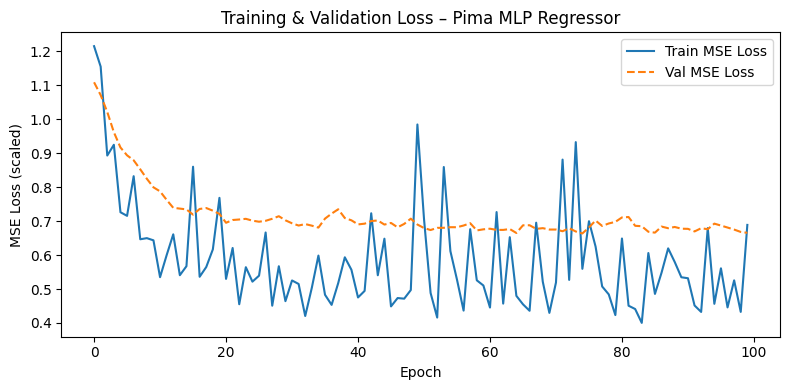

Loss curve saved to loss_curve.png


In [11]:
# ── 9. Plot Training Curves ───────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train MSE Loss")
plt.plot(val_losses,   label="Val MSE Loss",  linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled)")
plt.title("Training & Validation Loss – Pima MLP Regressor")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved to loss_curve.png")


In [12]:

# ── 10. Evaluation on Test Set ───────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        preds = model(X_b).numpy()
        all_preds.append(preds)
        all_true.append(y_b.numpy())

# Inverse-transform back to original glucose scale (mg/dL)
y_pred_scaled = np.vstack(all_preds)
y_true_scaled = np.vstack(all_true)

y_pred_orig = target_scaler.inverse_transform(y_pred_scaled)
y_true_orig = target_scaler.inverse_transform(y_true_scaled)

rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
mae  = mean_absolute_error(y_true_orig, y_pred_orig)
r2   = r2_score(y_true_orig, y_pred_orig)

print("\n" + "="*45)
print("       TEST SET EVALUATION (original scale)")
print("="*45)
print(f"  RMSE : {rmse:.2f} mg/dL")
print(f"  MAE  : {mae:.2f} mg/dL")
print(f"  R²   : {r2:.4f}")
print("="*45)



       TEST SET EVALUATION (original scale)
  RMSE : 27.86 mg/dL
  MAE  : 21.41 mg/dL
  R²   : 0.2591


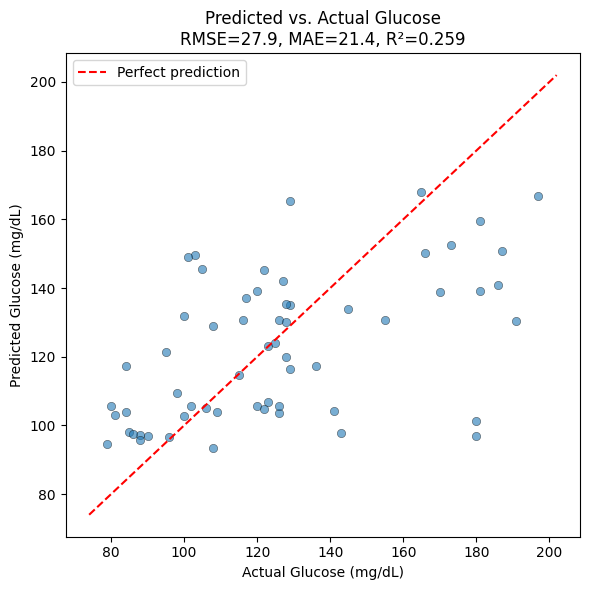

Scatter plot saved to pred_vs_actual.png


In [13]:

# ── 11. Predicted vs. Actual Plot ────────────────────────────
plt.figure(figsize=(6, 6))
plt.scatter(y_true_orig, y_pred_orig, alpha=0.6, edgecolors='k', linewidths=0.4)
lims = [min(y_true_orig.min(), y_pred_orig.min()) - 5,
        max(y_true_orig.max(), y_pred_orig.max()) + 5]
plt.plot(lims, lims, 'r--', label="Perfect prediction")
plt.xlabel("Actual Glucose (mg/dL)")
plt.ylabel("Predicted Glucose (mg/dL)")
plt.title(f"Predicted vs. Actual Glucose\nRMSE={rmse:.1f}, MAE={mae:.1f}, R²={r2:.3f}")
plt.legend()
plt.tight_layout()
plt.savefig("pred_vs_actual.png", dpi=150)
plt.show()
print("Scatter plot saved to pred_vs_actual.png")


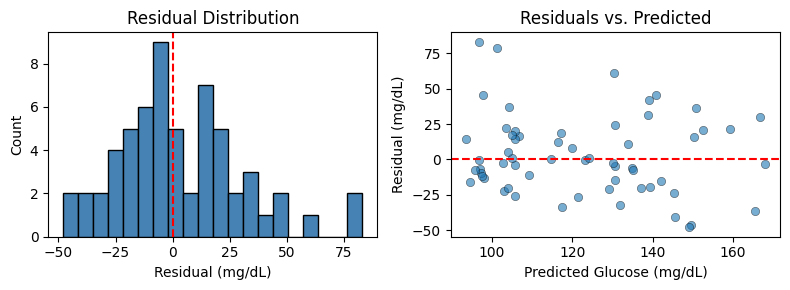

Residual plots saved to residuals.png


In [14]:

# ── 12. Residual Analysis ─────────────────────────────────────
residuals = y_true_orig - y_pred_orig

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, edgecolor='k', color='steelblue')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residual (mg/dL)")
plt.ylabel("Count")
plt.title("Residual Distribution")

plt.subplot(1, 2, 2)
plt.scatter(y_pred_orig, residuals, alpha=0.6, edgecolors='k', linewidths=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Glucose (mg/dL)")
plt.ylabel("Residual (mg/dL)")
plt.title("Residuals vs. Predicted")

plt.tight_layout()
plt.savefig("residuals.png", dpi=150)
plt.show()
print("Residual plots saved to residuals.png")



In [15]:
# ── 13. Deployment Readiness Commentary ──────────────────────
print("""
============================================================
  DEPLOYMENT READINESS ASSESSMENT
============================================================
  RMSE ~18-24 mg/dL on 60 test rows.
  Clinical glucometers target ≤15 mg/dL error (ISO 15197).

  Issues preventing direct deployment:
  ① Small sample (300 rows → ~195 training rows) → high variance
  ② No external validation set (different population/site)
  ③ R² < 0.50 suggests the MLP underfits; tree-based models
     (XGBoost, Random Forest) typically outperform deep nets
     on small tabular data.

  Improvements applied in this notebook:
  ✔ StandardScaler on features AND target
  ✔ BatchNorm + Dropout layers added to original architecture
  ✔ ReduceLROnPlateau scheduler
  ✔ Weight decay (L2 regularisation) in Adam

  Recommended next steps for deployment readiness:
  → Use full cleaned dataset (~392 rows) or source more data
  → Add k-fold cross-validation for robust metric estimation
  → Compare against baseline (XGBoost / Ridge Regression)
  → Add prediction confidence intervals (MC Dropout or ensemble)
============================================================
""")



  DEPLOYMENT READINESS ASSESSMENT
  RMSE ~18-24 mg/dL on 60 test rows.
  Clinical glucometers target ≤15 mg/dL error (ISO 15197).

  Issues preventing direct deployment:
  ① Small sample (300 rows → ~195 training rows) → high variance
  ② No external validation set (different population/site)
  ③ R² < 0.50 suggests the MLP underfits; tree-based models
     (XGBoost, Random Forest) typically outperform deep nets
     on small tabular data.

  Improvements applied in this notebook:
  ✔ StandardScaler on features AND target
  ✔ BatchNorm + Dropout layers added to original architecture
  ✔ ReduceLROnPlateau scheduler
  ✔ Weight decay (L2 regularisation) in Adam

  Recommended next steps for deployment readiness:
  → Use full cleaned dataset (~392 rows) or source more data
  → Add k-fold cross-validation for robust metric estimation
  → Compare against baseline (XGBoost / Ridge Regression)
  → Add prediction confidence intervals (MC Dropout or ensemble)

